<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Pop_Pyramid_Clustering/blob/main/PopCluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used PCA for Spec and HIer clustering (get optimal no of clusters and pca components )

Reduced dimensions to: 6


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Optimal clusters based on Silhouette Score: 3


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


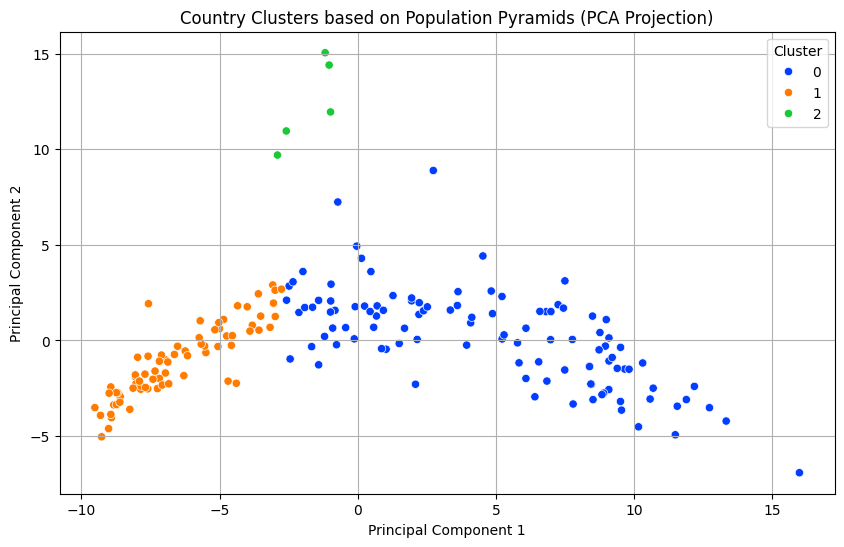

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# 1. Load Data
df = pd.read_csv('age_data_1.csv')

# Filter for the year 2020
df_2020 = df[df['Time'] == 2020].copy()

# 2. Feature Engineering for Population Pyramids
# Identify columns representing population counts
population_value_cols = ['PopMale', 'PopFemale', 'PopTotal'] # Assuming these are the population count columns

# Ensure these columns are numeric, coercing errors and filling NaNs with 0
for col in population_value_cols:
    if col in df_2020.columns: # Check if column exists
        df_2020[col] = pd.to_numeric(df_2020[col], errors='coerce').fillna(0)

# Reshape the data for country-level clustering.
# Each row should be a country, and columns should be population counts per age group and gender.
# First, melt the population columns to long format
df_long = df_2020.melt(
    id_vars=['Location', 'Time', 'AgeGrp'],
    value_vars=population_value_cols,
    var_name='PopulationType', # e.g., 'PopMale', 'PopFemale'
    value_name='PopulationValue'
)

# Create a combined 'Feature' column (e.g., 'PopMale_0-4', 'PopFemale_5-9')
df_long['Feature'] = df_long['PopulationType'] + '_' + df_long['AgeGrp']

# Pivot the table to get countries as rows and features as columns
X_pivoted = df_long.pivot_table(
    index='Location',
    columns='Feature',
    values='PopulationValue',
    aggfunc='sum' # Aggregate in case of multiple entries (should ideally be unique per Location-AgeGrp-PopulationType)
)

# Fill any NaNs that might arise from pivoting (e.g., if a country is missing an age group entirely)
X = X_pivoted.fillna(0)

# Ensure all columns in X are numeric after pivoting (should be from previous steps, but safe check)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. Normalization (Percentage of total population for each country)
# Sum across columns for each country to get its total population represented in X
total_population_per_country = X.sum(axis=1)

# Replace 0 sums with 1 to avoid division by zero errors; countries with 0 total pop will have 0% for all features
total_population_per_country[total_population_per_country == 0] = 1

X_pct = X.div(total_population_per_country, axis=0)

# 4. Standardizing for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# 5. Dimensionality Reduction (PCA)
pca = PCA(n_components=0.95) # Keep 95% of variance
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced dimensions to: {X_pca.shape[1]}")

# 6. Finding Optimal Clusters (Silhouette Method)
# We test a range to find the best 'k'
scores = []
k_range = range(2, 8)
for k in k_range:
    # Using 'nearest_neighbors' for affinity requires n_neighbors <= n_samples
    # Ensure n_neighbors is not greater than the number of samples (countries)
    n_neighbors_val = min(k + 1, X_pca.shape[0] -1 ) # Ensure n_neighbors is at least 1 and less than n_samples
    if n_neighbors_val < 2: # SpectralClustering requires n_neighbors >= 2
        n_neighbors_val = 2

    sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val, random_state=42)
    labels = sc.fit_predict(X_pca)
    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster for meaningful score
    if len(np.unique(labels)) > 1:
        scores.append(silhouette_score(X_pca, labels))
    else:
        scores.append(-1) # Assign a low score if only one cluster found or issue prevents score

# If all scores are -1 (meaning no valid silhouette scores were computed), handle this case
if max(scores) == -1:
    optimal_k = k_range[0] # Default to the smallest k if no valid scores
    print("Warning: Could not compute valid silhouette scores for most k values. Defaulting to smallest k.")
elif len(scores) > 0:
    optimal_k = k_range[np.argmax(scores)]
else:
    optimal_k = 2 # Default to 2 if no scores were appended at all

print(f"Optimal clusters based on Silhouette Score: {optimal_k}")

# 7. Final Clustering
# Ensure n_neighbors is valid for the final model as well
n_neighbors_val_final = min(optimal_k + 1, X_pca.shape[0] -1)
if n_neighbors_val_final < 2:
    n_neighbors_val_final = 2

model = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val_final, random_state=42)
cluster_labels = model.fit_predict(X_pca)

# Add cluster labels back to the pivoted DataFrame (X_pct or X, as they have 'Location' as index)
X['Cluster'] = cluster_labels

# 8. Visualization of PCA Components
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=X['Cluster'], palette='bright')
plt.title('Country Clusters based on Population Pyramids (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

#Spectral Clustering - 2020 using PCA

In [4]:
# 9. Print Country Lists for each Cluster
print("\n" + "="*50)
print("COUNTRY LISTS BY CLUSTER")
print("="*50)

# Define descriptive labels based on common demographic trends
# Note: You can swap these if your PCA projection assigns numbers differently
cluster_meanings = {
    0: "High Growth / Expansive (Young Population)",
    1: "Transitional / Bulge (Working-Age Dividend)",
    2: "Aging / Constrictive (Post-Transitional)"
}

for cluster_id in range(optimal_k):
    # Get index (Country names) where cluster matches
    countries = X[X['Cluster'] == cluster_id].index.tolist()

    label = cluster_meanings.get(cluster_id, f"Cluster {cluster_id}")

    print(f"\n--- {label} ---")
    print(f"Total Count: {len(countries)}")
    # Join list into a comma-separated string for readability
    print(", ".join(countries))
    print("-" * 30)

# Optional: Export to CSV
# X[['Cluster']].to_csv('countries_by_cluster.csv')


COUNTRY LISTS BY CLUSTER

--- High Growth / Expansive (Young Population) ---
Total Count: 107
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belgium, Bhutan, Bolivia (Plurinational State of), Bosnia and Herzegovina, Brazil, Brunei Darussalam, Bulgaria, Canada, Chile, China, China, Taiwan Province of China, Colombia, Costa Rica, Croatia, Cuba, Curaçao, Cyprus, Czechia, Dem. People's Republic of Korea, Denmark, Dominican Republic, Ecuador, El Salvador, Estonia, Fiji, Finland, France, Georgia, Germany, Greece, Grenada, Guam, Guyana, Hungary, Iceland, India, Indonesia, Iran (Islamic Republic of), Ireland, Israel, Italy, Jamaica, Japan, Kazakhstan, Kuwait, Latvia, Lebanon, Libya, Lithuania, Luxembourg, Malaysia, Malta, Mauritius, Mexico, Mongolia, Montenegro, Morocco, Myanmar, Netherlands, New Zealand, North Macedonia, Northern Europe, Norway, Panama, Peru, Poland, Portugal, Puerto Rico, Republic of Korea, 

#Specral Clustering - 2020 world map

In [5]:
import plotly.express as px

# 1. Prepare the data for mapping
map_df = X[['Cluster']].reset_index()

# --- FIX FOR DENMARK/GREENLAND ---
# Check if Denmark exists in your data
if 'Denmark' in map_df['Location'].values:
    # Pull the row for Denmark
    denmark_row = map_df[map_df['Location'] == 'Denmark'].copy()
    # Change the name to Greenland
    denmark_row['Location'] = 'Greenland'
    # Add it back to the dataframe
    map_df = pd.concat([map_df, denmark_row], ignore_index=True)
# ---------------------------------

# 2. Define Descriptive Labels
cluster_labels = {
    0: "Cluster 0: High Growth (Young)",
    1: "Cluster 1: Transitional (Working Age)",
    2: "Cluster 2: Aging (Post-Transitional)"
}
map_df['Demographic Stage'] = map_df['Cluster'].map(cluster_labels)

# 3. Create the Interactive Choropleth Map
fig = px.choropleth(
    map_df,
    locations="Location",
    locationmode="country names",
    color="Demographic Stage",
    hover_name="Location",
    title="Global Demographic Clusters 2020 (Including Greenland/Denmark Fix)",
    color_discrete_sequence=px.colors.qualitative.Safe
)

# 4. Refine Map Appearance
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    legend_title_text='Demographic Cluster',
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

# Hier clustering part

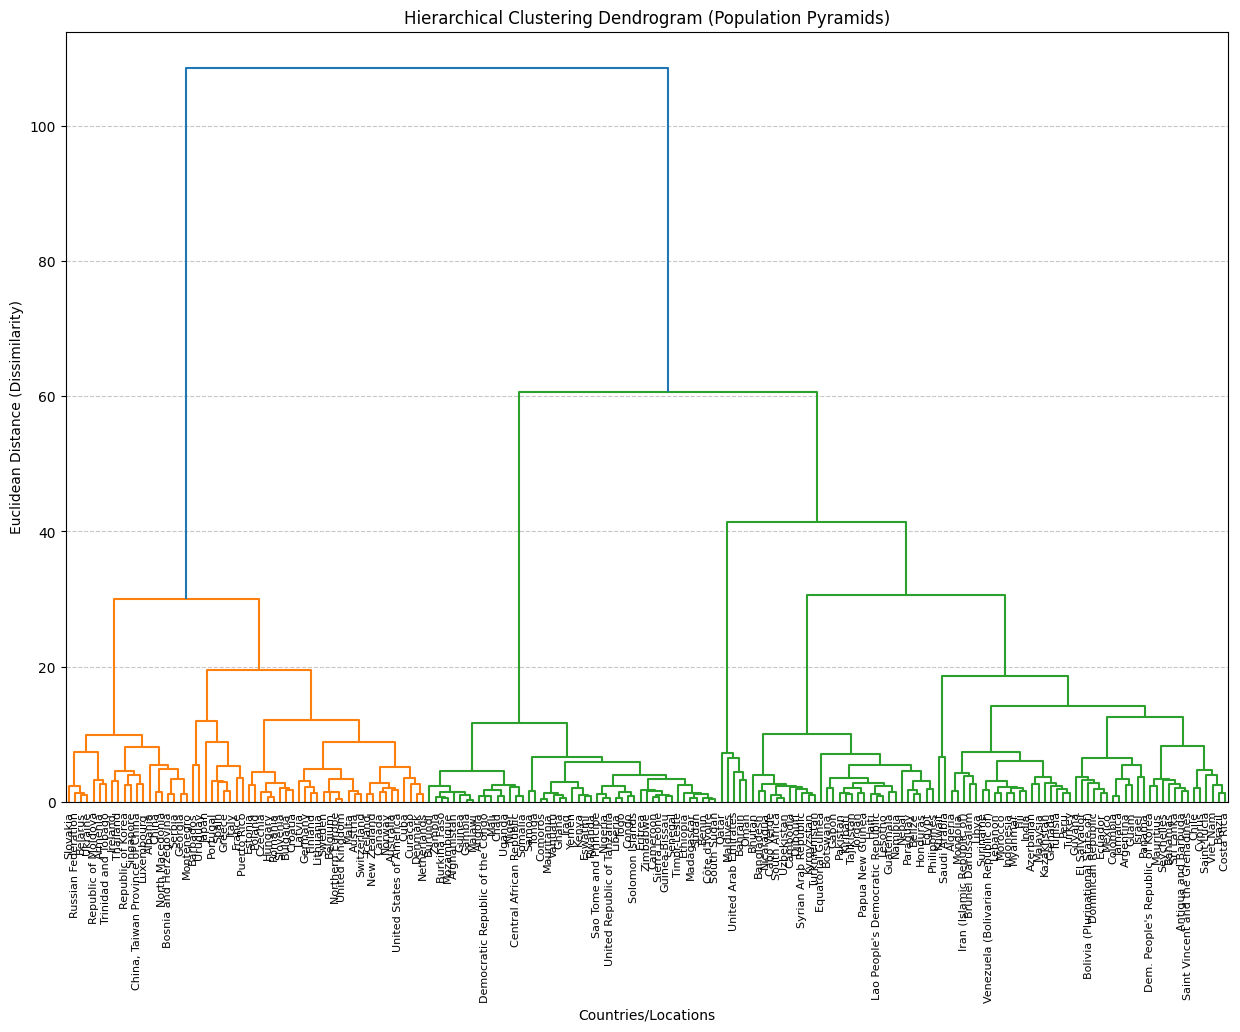


HIERARCHICAL CLUSTERING RESULTS

Cluster 0 - Count: 82
Algeria, Antigua and Barbuda, Argentina, Azerbaijan, Bahamas, Bahrain, Bangladesh, Belize, Bhutan, Bolivia (Plurinational State of), Botswana, Brazil, Brunei Darussalam, Cabo Verde, Cambodia...

Cluster 1 - Count: 58
Albania, Armenia, Australia, Austria, Barbados, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, China, China, Taiwan Province of China, Croatia, Cuba, Curaçao...

Cluster 2 - Count: 47
Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Côte d'Ivoire, Democratic Republic of the Congo, Eritrea, Eswatini, Ethiopia...


In [6]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Generate the Linkage Matrix
# 'ward' linkage minimizes the variance within clusters (works best with PCA data)
Z = sch.linkage(X_pca, method='ward')

# 2. Plot the Dendrogram
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(
    Z,
    labels=X.index,  # Uses country names from the index
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Population Pyramids)')
plt.xlabel('Countries/Locations')
plt.ylabel('Euclidean Distance (Dissimilarity)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Fit Agglomerative Clustering
# We use the same optimal_k found by your silhouette score previously
hc_model = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
X['HC_Cluster'] = hc_model.fit_predict(X_pca)

# 4. Compare and Print the Country Lists
print("\n" + "="*50)
print("HIERARCHICAL CLUSTERING RESULTS")
print("="*50)

for cluster_id in range(optimal_k):
    countries = X[X['HC_Cluster'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id} - Count: {len(countries)}")
    print(", ".join(countries[:15]) + ("..." if len(countries) > 15 else ""))

#Score s between spec and hier

In [7]:
from sklearn.metrics import silhouette_score

spectral_score = silhouette_score(X_pca, X['Cluster'])
hierarchical_score = silhouette_score(X_pca, X['HC_Cluster'])

print(f"\nSilhouette Score (Spectral): {spectral_score:.4f}")
print(f"Silhouette Score (Hierarchical): {hierarchical_score:.4f}")


Silhouette Score (Spectral): 0.4632
Silhouette Score (Hierarchical): 0.4130


#HIer clustering (2020)

In [8]:
import plotly.express as px
import pandas as pd

# 1. Prepare data for Hierarchical Map
map_hc_df = X[['HC_Cluster']].reset_index()

# --- DENMARK TO GREENLAND FIX ---
# Check if Denmark is in the list
if 'Denmark' in map_hc_df['Location'].values:
    # Create a copy of Denmark's data
    denmark_data = map_hc_df[map_hc_df['Location'] == 'Denmark'].copy()
    # Rename it to Greenland
    denmark_data['Location'] = 'Greenland'
    # Add it to the map dataframe
    map_hc_df = pd.concat([map_hc_df, denmark_data], ignore_index=True)
# ---------------------------------

# 2. Assign Descriptive Labels
hc_labels = {
    0: "HC Cluster 0: High Growth",
    1: "HC Cluster 1: Transitional",
    2: "HC Cluster 2: Aging"
}
map_hc_df['Demographic Stage (HC)'] = map_hc_df['HC_Cluster'].map(hc_labels)

# 3. Create the Map
fig_hc = px.choropleth(
    map_hc_df,
    locations="Location",
    locationmode="country names",
    color="Demographic Stage (HC)",
    hover_name="Location",
    title="World Map: Hierarchical Clustering (Including Greenland/Denmark Fix)",
    color_discrete_sequence=px.colors.qualitative.Bold
)

# 4. Final Layout Adjustments
fig_hc.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig_hc.show()

#Hier and Spec clustering world map comparison

In [12]:
import plotly.express as px
import pandas as pd

# 1. Prepare the base DataFrames
df_spec_map = X.reset_index()
df_hier_map = X.reset_index()

# Function to duplicate Denmark data for Greenland
def fix_greenland(map_df):
    if 'Denmark' in map_df['Location'].values:
        denmark_row = map_df[map_df['Location'] == 'Denmark'].copy()
        denmark_row['Location'] = 'Greenland'
        return pd.concat([map_df, denmark_row], ignore_index=True)
    return map_df

# Apply the fix to both dataframes
df_spec_map = fix_greenland(df_spec_map)
df_hier_map = fix_greenland(df_hier_map)

# Define consistent label mappings for both clustering methods
# These mappings ensure the cluster numbers (0, 1, 2) get the specific string labels
# expected by the color_discrete_map in the choropleth plots.
# For Spectral Clustering, we align with the meanings from previous cells.
spectral_labels_map = {
    0: "High Growth (Expansive)",
    1: "Transitional (Stationary)",
    2: "Aging (Constrictive)"
}

# For Hierarchical Clustering, we assume a similar order of demographic stages
# for its clusters (0, 1, 2) to match the intended visualization.
hierarchical_labels_map = {
    0: "High Growth (Expansive)",
    1: "Transitional (Stationary)",
    2: "Aging (Constrictive)"
}

# Add the 'Spectral_Label' and 'Hierarchical_Label' columns to the dataframes
df_spec_map['Spectral_Label'] = df_spec_map['Cluster'].map(spectral_labels_map)
df_hier_map['Hierarchical_Label'] = df_hier_map['HC_Cluster'].map(hierarchical_labels_map)

# 2. Visualization: Spectral World Map (Fixed)
fig_spec = px.choropleth(
    df_spec_map,
    locations="Location",
    locationmode="country names",
    color="Spectral_Label", # Now this column exists
    title="Spectral Clustering: Demographic Stages 2020 (Greenland Fixed)",
    color_discrete_map={
        "High Growth (Expansive)": "#EF553B",  # Red
        "Transitional (Stationary)": "#636EFA", # Blue
        "Aging (Constrictive)": "#00CC96"       # Green
    }
)
fig_spec.show()

# 3. Visualization: Hierarchical World Map (Fixed)
fig_hier = px.choropleth(
    df_hier_map,
    locations="Location",
    locationmode="country names",
    color="Hierarchical_Label", # Now this column exists
    title="Hierarchical Clustering: Demographic Stages 2020 (Greenland Fixed)",
    color_discrete_map={
        "High Growth (Expansive)": "#EF553B",
        "Transitional (Stationary)": "#636EFA",
        "Aging (Constrictive)": "#00CC96"
    }
)
fig_hier.show()

# 10 Countries spec- 2020

<>:13: SyntaxWarning:

invalid escape sequence '\d'

<>:13: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-3178899652.py:13: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or

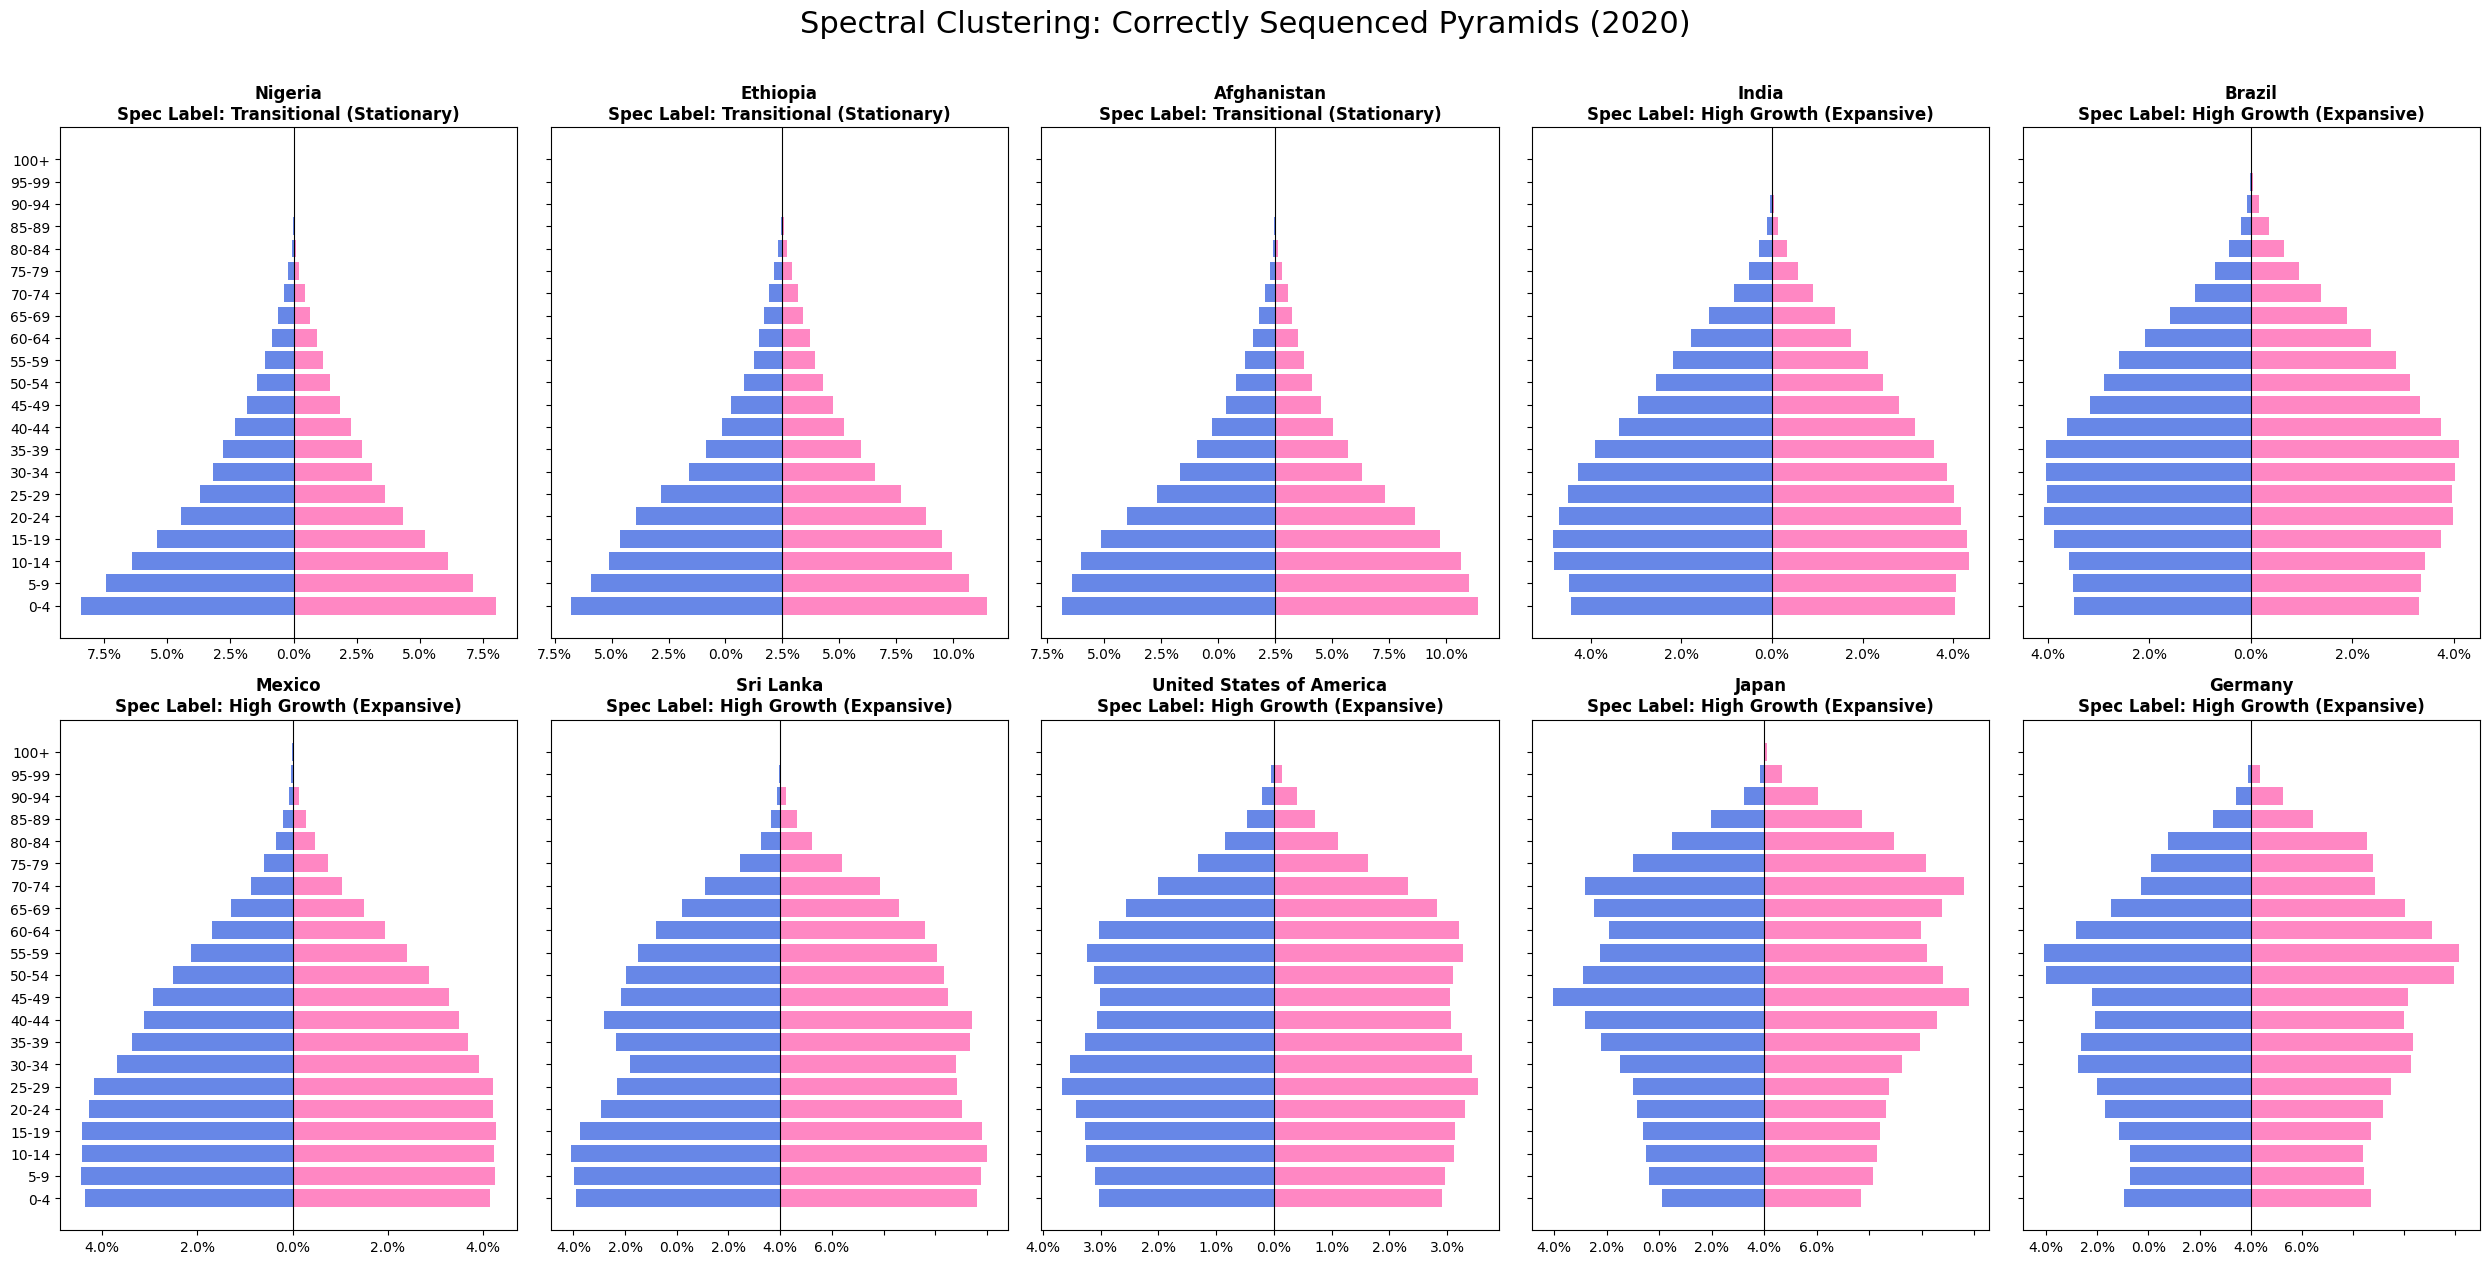

In [14]:
import matplotlib.pyplot as plt

# 1. Choose your 10 countries
countries_10 = ['Nigeria', 'Ethiopia', 'Afghanistan', 'India', 'Brazil',
                'Mexico', 'Sri Lanka', 'United States of America', 'Japan', 'Germany']

# 2. Setup the plot
fig, axes = plt.subplots(2, 5, figsize=(25, 12), sharey=True)
axes = axes.flatten()

# --- IMPORTANT: Create a sorting helper ---
# We extract the first number from the AgeGrp string (e.g., "5-9" -> 5) to sort correctly
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

# Define the spectral labels map (re-using from a previous cell or defining if needed)
spectral_labels_map = {
    0: "High Growth (Expansive)",
    1: "Transitional (Stationary)",
    2: "Aging (Constrictive)"
}

# Add 'Spectral_Label' to X DataFrame
X['Spectral_Label'] = X['Cluster'].map(spectral_labels_map)

for i, country in enumerate(countries_10):
    ax = axes[i]

    # Filter and SORT by our new helper column
    data = df[(df['Location'] == country) & (df['Time'] == 2020)].sort_values('age_sort')

    if data.empty: continue

    label = X.loc[country, 'Spectral_Label']
    total = data['PopTotal'].sum()
    m_pct = (data['PopMale'] / total) * 100
    f_pct = (data['PopFemale'] / total) * 100

    # Plot
    ax.barh(data['AgeGrp'], -m_pct, color='royalblue', alpha=0.8, label='Male')
    ax.barh(data['AgeGrp'], f_pct, color='hotpink', alpha=0.8, label='Female')
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{country}\nSpec Label: {label}", fontsize=12, fontweight='bold')

    # Formatting X-axis to show positive numbers on both sides
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Spectral Clustering: Correctly Sequenced Pyramids (2020)", fontsize=22, y=1.05)
plt.show()

# 10 countries - HIer 2020

/tmp/ipython-input-2389919720.py:46: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2389919720.py:46: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2389919720.py:46: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2389919720.py:46: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2389919720.py:46: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2389919720.py:46: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

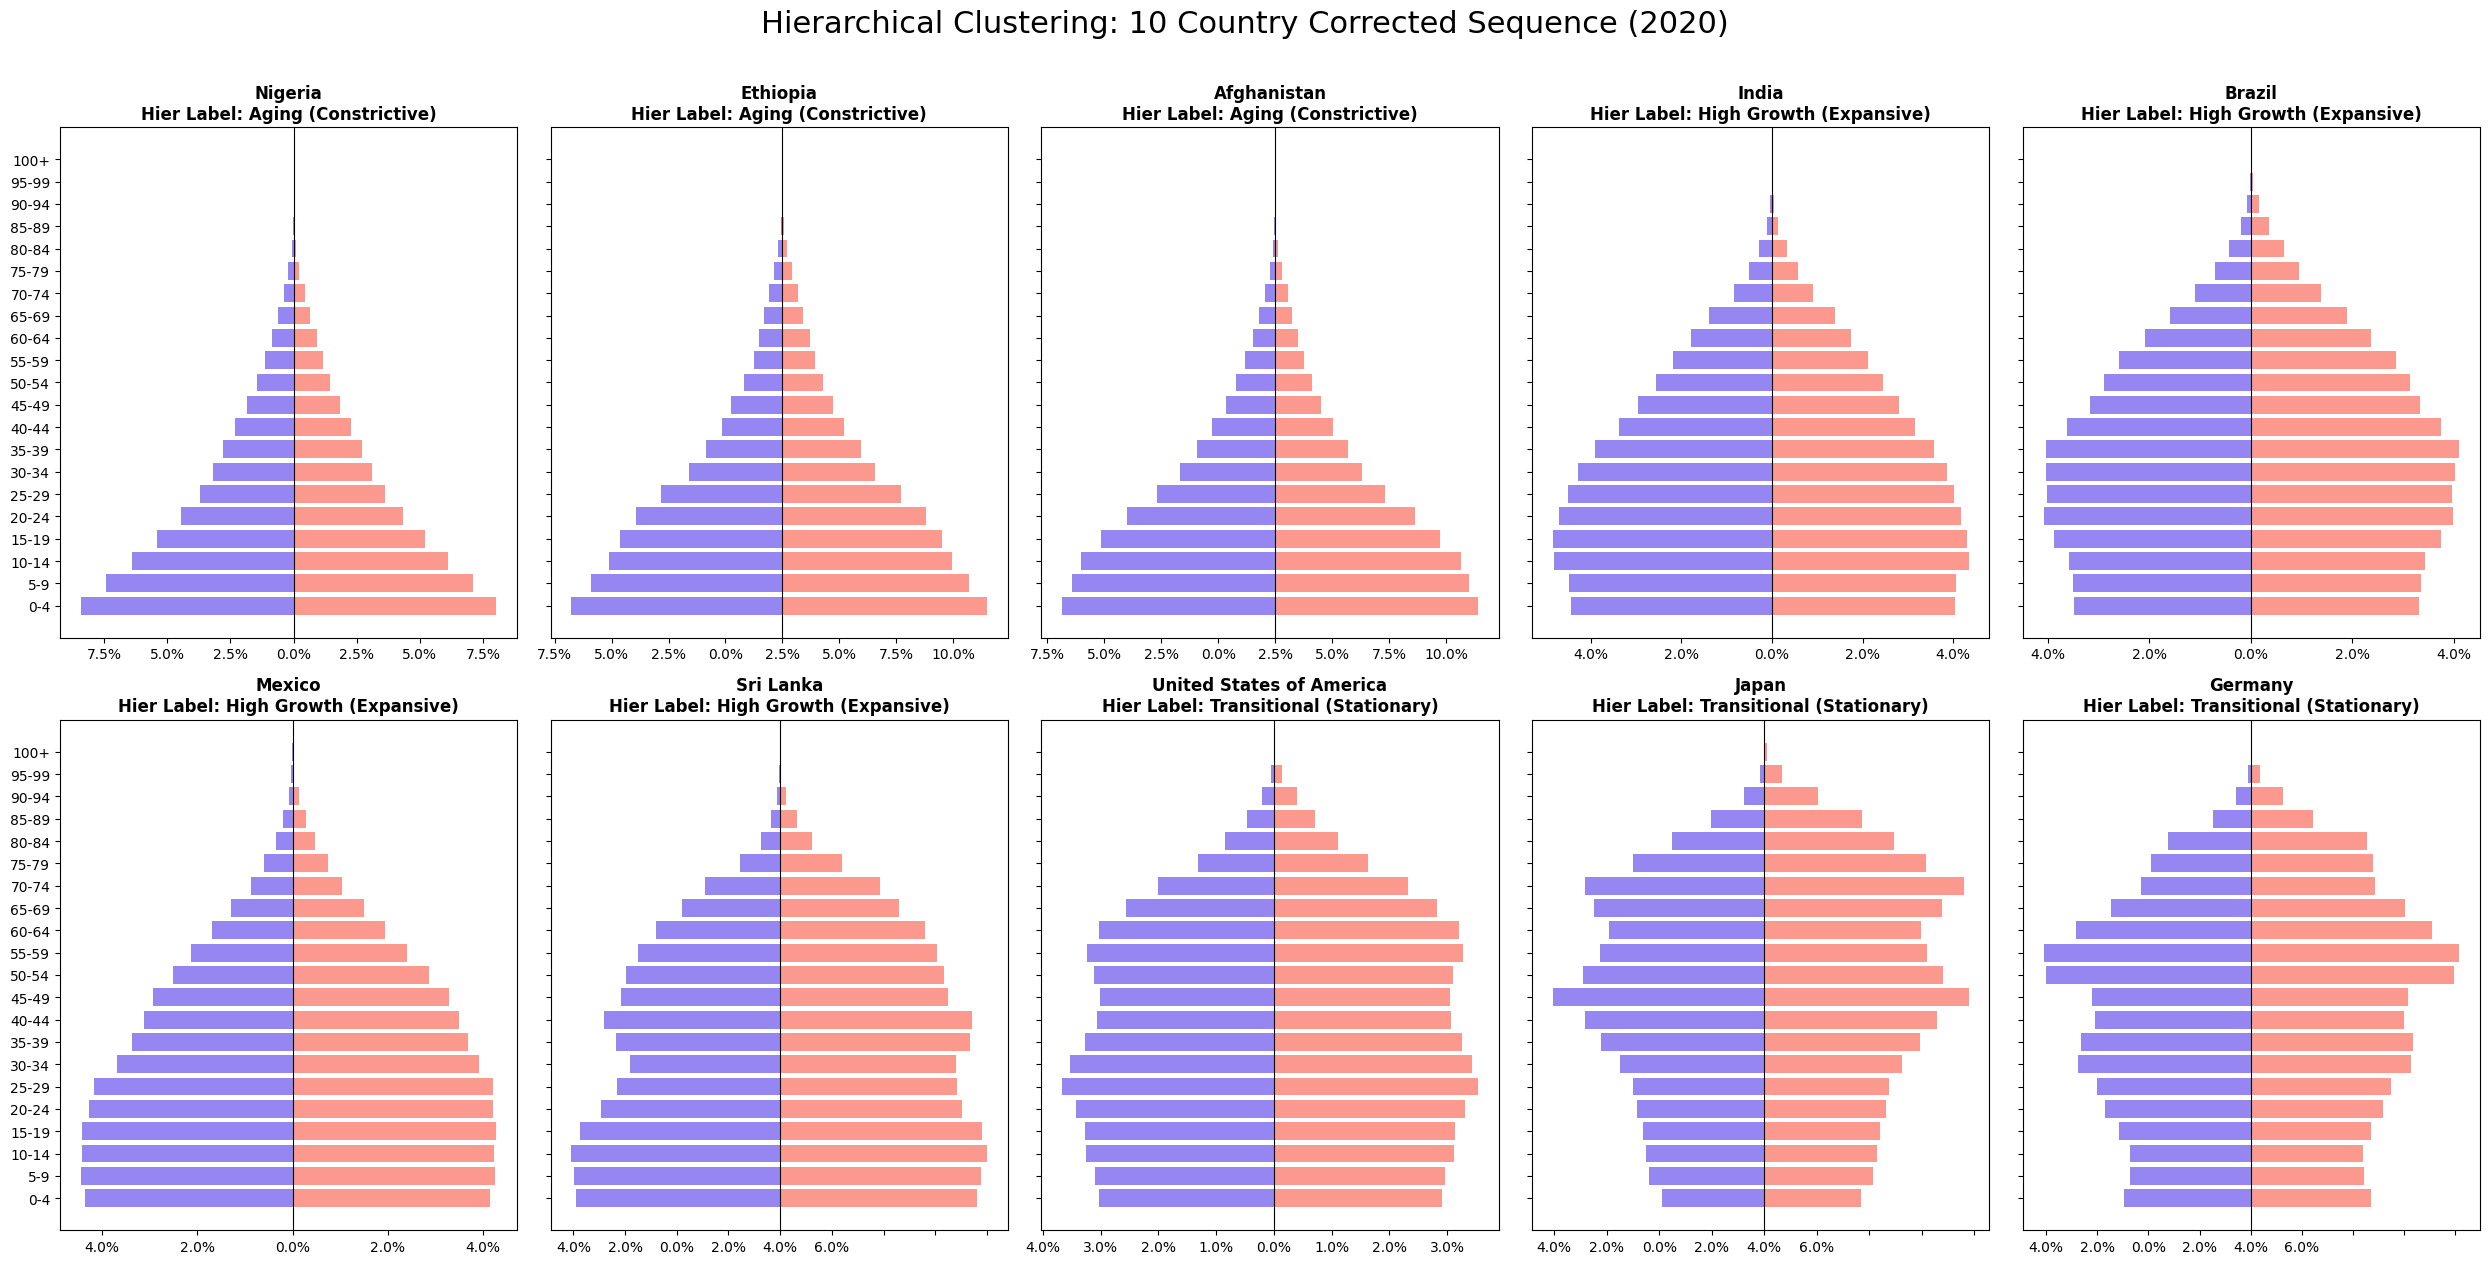

In [16]:
import matplotlib.pyplot as plt

# 1. Setup the figure
fig, axes = plt.subplots(2, 5, figsize=(25, 12), sharey=True)
axes = axes.flatten()

# --- THE FIX: Extract number from string for correct sorting ---
# This ensures 5-9 comes before 10-14
df['age_sort'] = df['AgeGrp'].str.extract('(\\d+)').astype(float)

# Define the hierarchical labels map (re-using from a previous cell or defining if needed)
hierarchical_labels_map = {
    0: "High Growth (Expansive)",
    1: "Transitional (Stationary)",
    2: "Aging (Constrictive)"
}

# Add 'Hierarchical_Label' to X DataFrame
X['Hierarchical_Label'] = X['HC_Cluster'].map(hierarchical_labels_map)

for i, country in enumerate(countries_10):
    ax = axes[i]

    # Filter and SORT correctly using age_sort
    data = df[(df['Location'] == country) & (df['Time'] == 2020)].sort_values('age_sort')

    if data.empty: continue

    # Get the Hierarchical Label
    label = X.loc[country, 'Hierarchical_Label']

    # Calculate percentages
    total = data['PopTotal'].sum()
    m_pct = (data['PopMale'] / total) * 100
    f_pct = (data['PopFemale'] / total) * 100

    # Plot with Hierarchical specific colors (Slate Blue & Salmon)
    ax.barh(data['AgeGrp'], -m_pct, color='mediumslateblue', alpha=0.8, label='Male')
    ax.barh(data['AgeGrp'], f_pct, color='salmon', alpha=0.8, label='Female')
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{country}\nHier Label: {label}", fontsize=12, fontweight='bold')

    # Formatting X-axis
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Hierarchical Clustering: 10 Country Corrected Sequence (2020)", fontsize=22, y=1.05)
plt.show()

#Comparison Table

In [17]:
# Create the comparison table
comparison_df = X[['Cluster', 'Spectral_Label', 'HC_Cluster', 'Hierarchical_Label']].copy()
comparison_df.reset_index(inplace=True)

# Sort by Spectral Label to keep groups together
comparison_df = comparison_df.sort_values(by=['Spectral_Label', 'Location'])

# Display the first few rows of the table
print(comparison_df.head(20))

# Save the final table to CSV for your report
comparison_df.to_csv('country_clustering_comparison.csv', index=False)
print("\nSuccess: 'country_clustering_comparison.csv' has been created.")

Feature                          Location  Cluster           Spectral_Label  \
11                                Bahrain        2     Aging (Constrictive)   
104                              Maldives        2     Aging (Constrictive)   
125                                  Oman        2     Aging (Constrictive)   
135                                 Qatar        2     Aging (Constrictive)   
175                  United Arab Emirates        2     Aging (Constrictive)   
1                                 Albania        0  High Growth (Expansive)   
2                                 Algeria        0  High Growth (Expansive)   
4                     Antigua and Barbuda        0  High Growth (Expansive)   
5                               Argentina        0  High Growth (Expansive)   
6                                 Armenia        0  High Growth (Expansive)   
7                               Australia        0  High Growth (Expansive)   
8                                 Austria        0  

#Spec vs Hier(Diffrent Countries)

In [18]:
# Find countries where the two methods disagree
mismatches = comparison_df[comparison_df['Spectral_Label'] != comparison_df['Hierarchical_Label']]
print(f"Number of countries with different classifications: {len(mismatches)}")
print(mismatches[['Location', 'Spectral_Label', 'Hierarchical_Label']])

Number of countries with different classifications: 138
Feature              Location             Spectral_Label  \
11                    Bahrain       Aging (Constrictive)   
104                  Maldives       Aging (Constrictive)   
125                      Oman       Aging (Constrictive)   
135                     Qatar       Aging (Constrictive)   
175      United Arab Emirates       Aging (Constrictive)   
..                        ...                        ...   
180                Uzbekistan  Transitional (Stationary)   
181                   Vanuatu  Transitional (Stationary)   
184                     Yemen  Transitional (Stationary)   
185                    Zambia  Transitional (Stationary)   
186                  Zimbabwe  Transitional (Stationary)   

Feature       Hierarchical_Label  
11       High Growth (Expansive)  
104      High Growth (Expansive)  
125      High Growth (Expansive)  
135      High Growth (Expansive)  
175      High Growth (Expansive)  
..           

#Apply UMAP for visulaization

In [19]:
import umap
from sklearn.preprocessing import StandardScaler

# Standardize the percentage data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# Apply UMap
# n_neighbors: looks at local vs global structure (15 is a good balance)
# min_dist: how tightly points pack together (0.1 is standard)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Add UMap coordinates to our dataframe for easy plotting
X['UMAP_1'] = X_umap[:, 0]
X['UMAP_2'] = X_umap[:, 1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



###Spectral Clustering UMAP

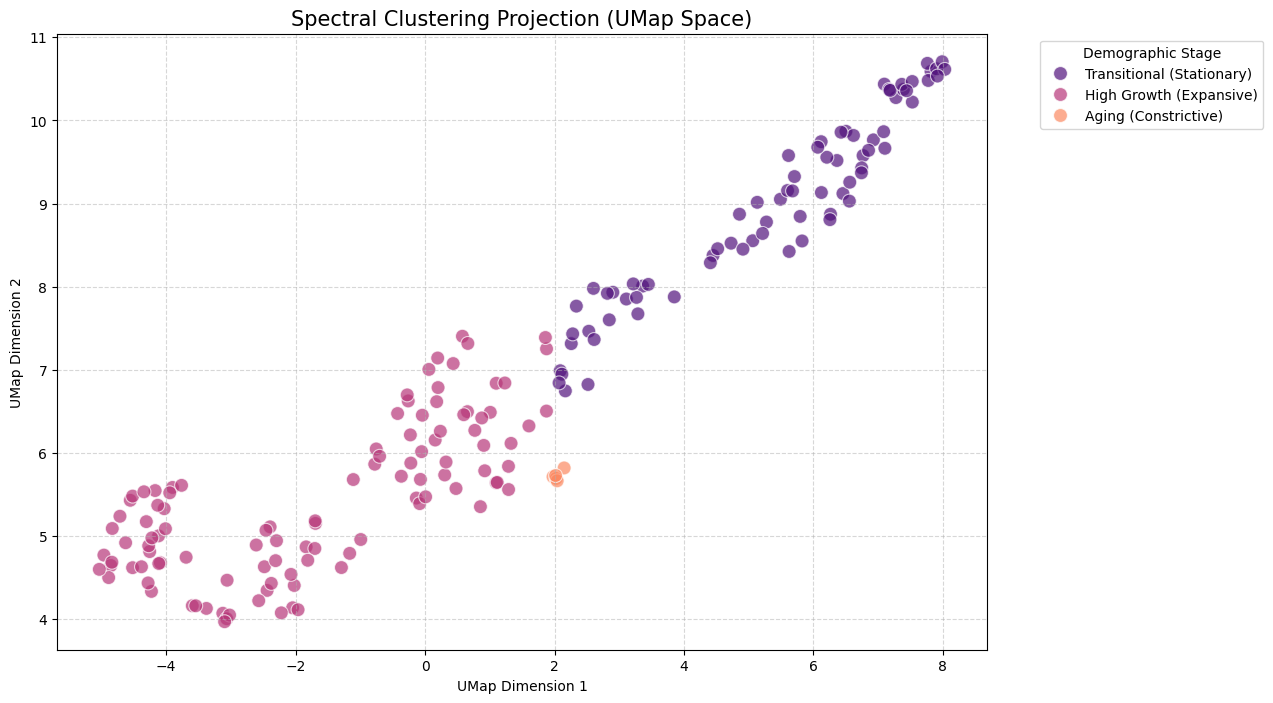

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# We use the Cluster labels already generated by your Spectral model
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP_1', y='UMAP_2',
    hue='Spectral_Label',
    data=X,
    palette='magma', # Uses a rainbow-like palette for stages
    s=100, alpha=0.7, edgecolor='w'
)

plt.title('Spectral Clustering Projection (UMap Space)', fontsize=15)
plt.xlabel('UMap Dimension 1')
plt.ylabel('UMap Dimension 2')
plt.legend(title='Demographic Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###UMAP for HIer

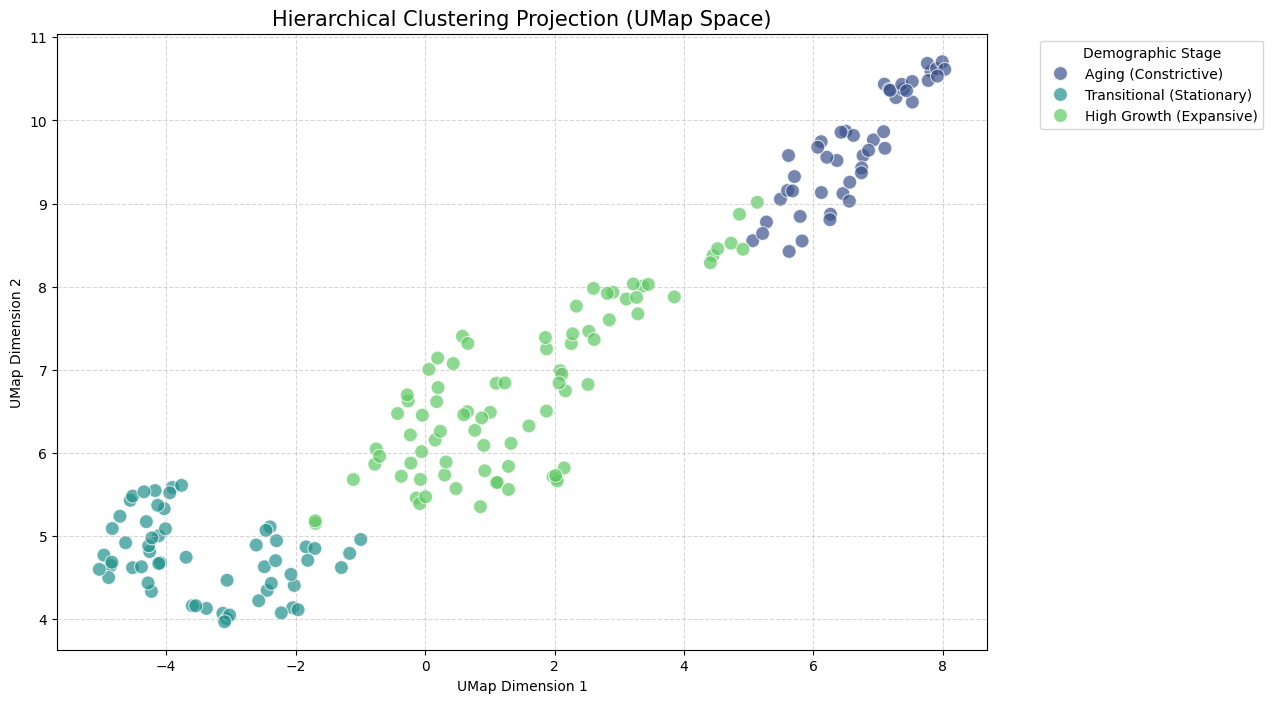

In [21]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP_1', y='UMAP_2',
    hue='Hierarchical_Label',
    data=X,
    palette='viridis', # Distinctly different colors for the tree-based model
    s=100, alpha=0.7, edgecolor='w'
)

plt.title('Hierarchical Clustering Projection (UMap Space)', fontsize=15)
plt.xlabel('UMap Dimension 1')
plt.ylabel('UMap Dimension 2')
plt.legend(title='Demographic Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#DEmo. Ev.. from 1950 to 2100 Spectral

<>:9: SyntaxWarning:

invalid escape sequence '\d'

<>:9: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-3916640664.py:9: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-3916640664.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3916640664.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3916640664.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3916640664.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-3916640664.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

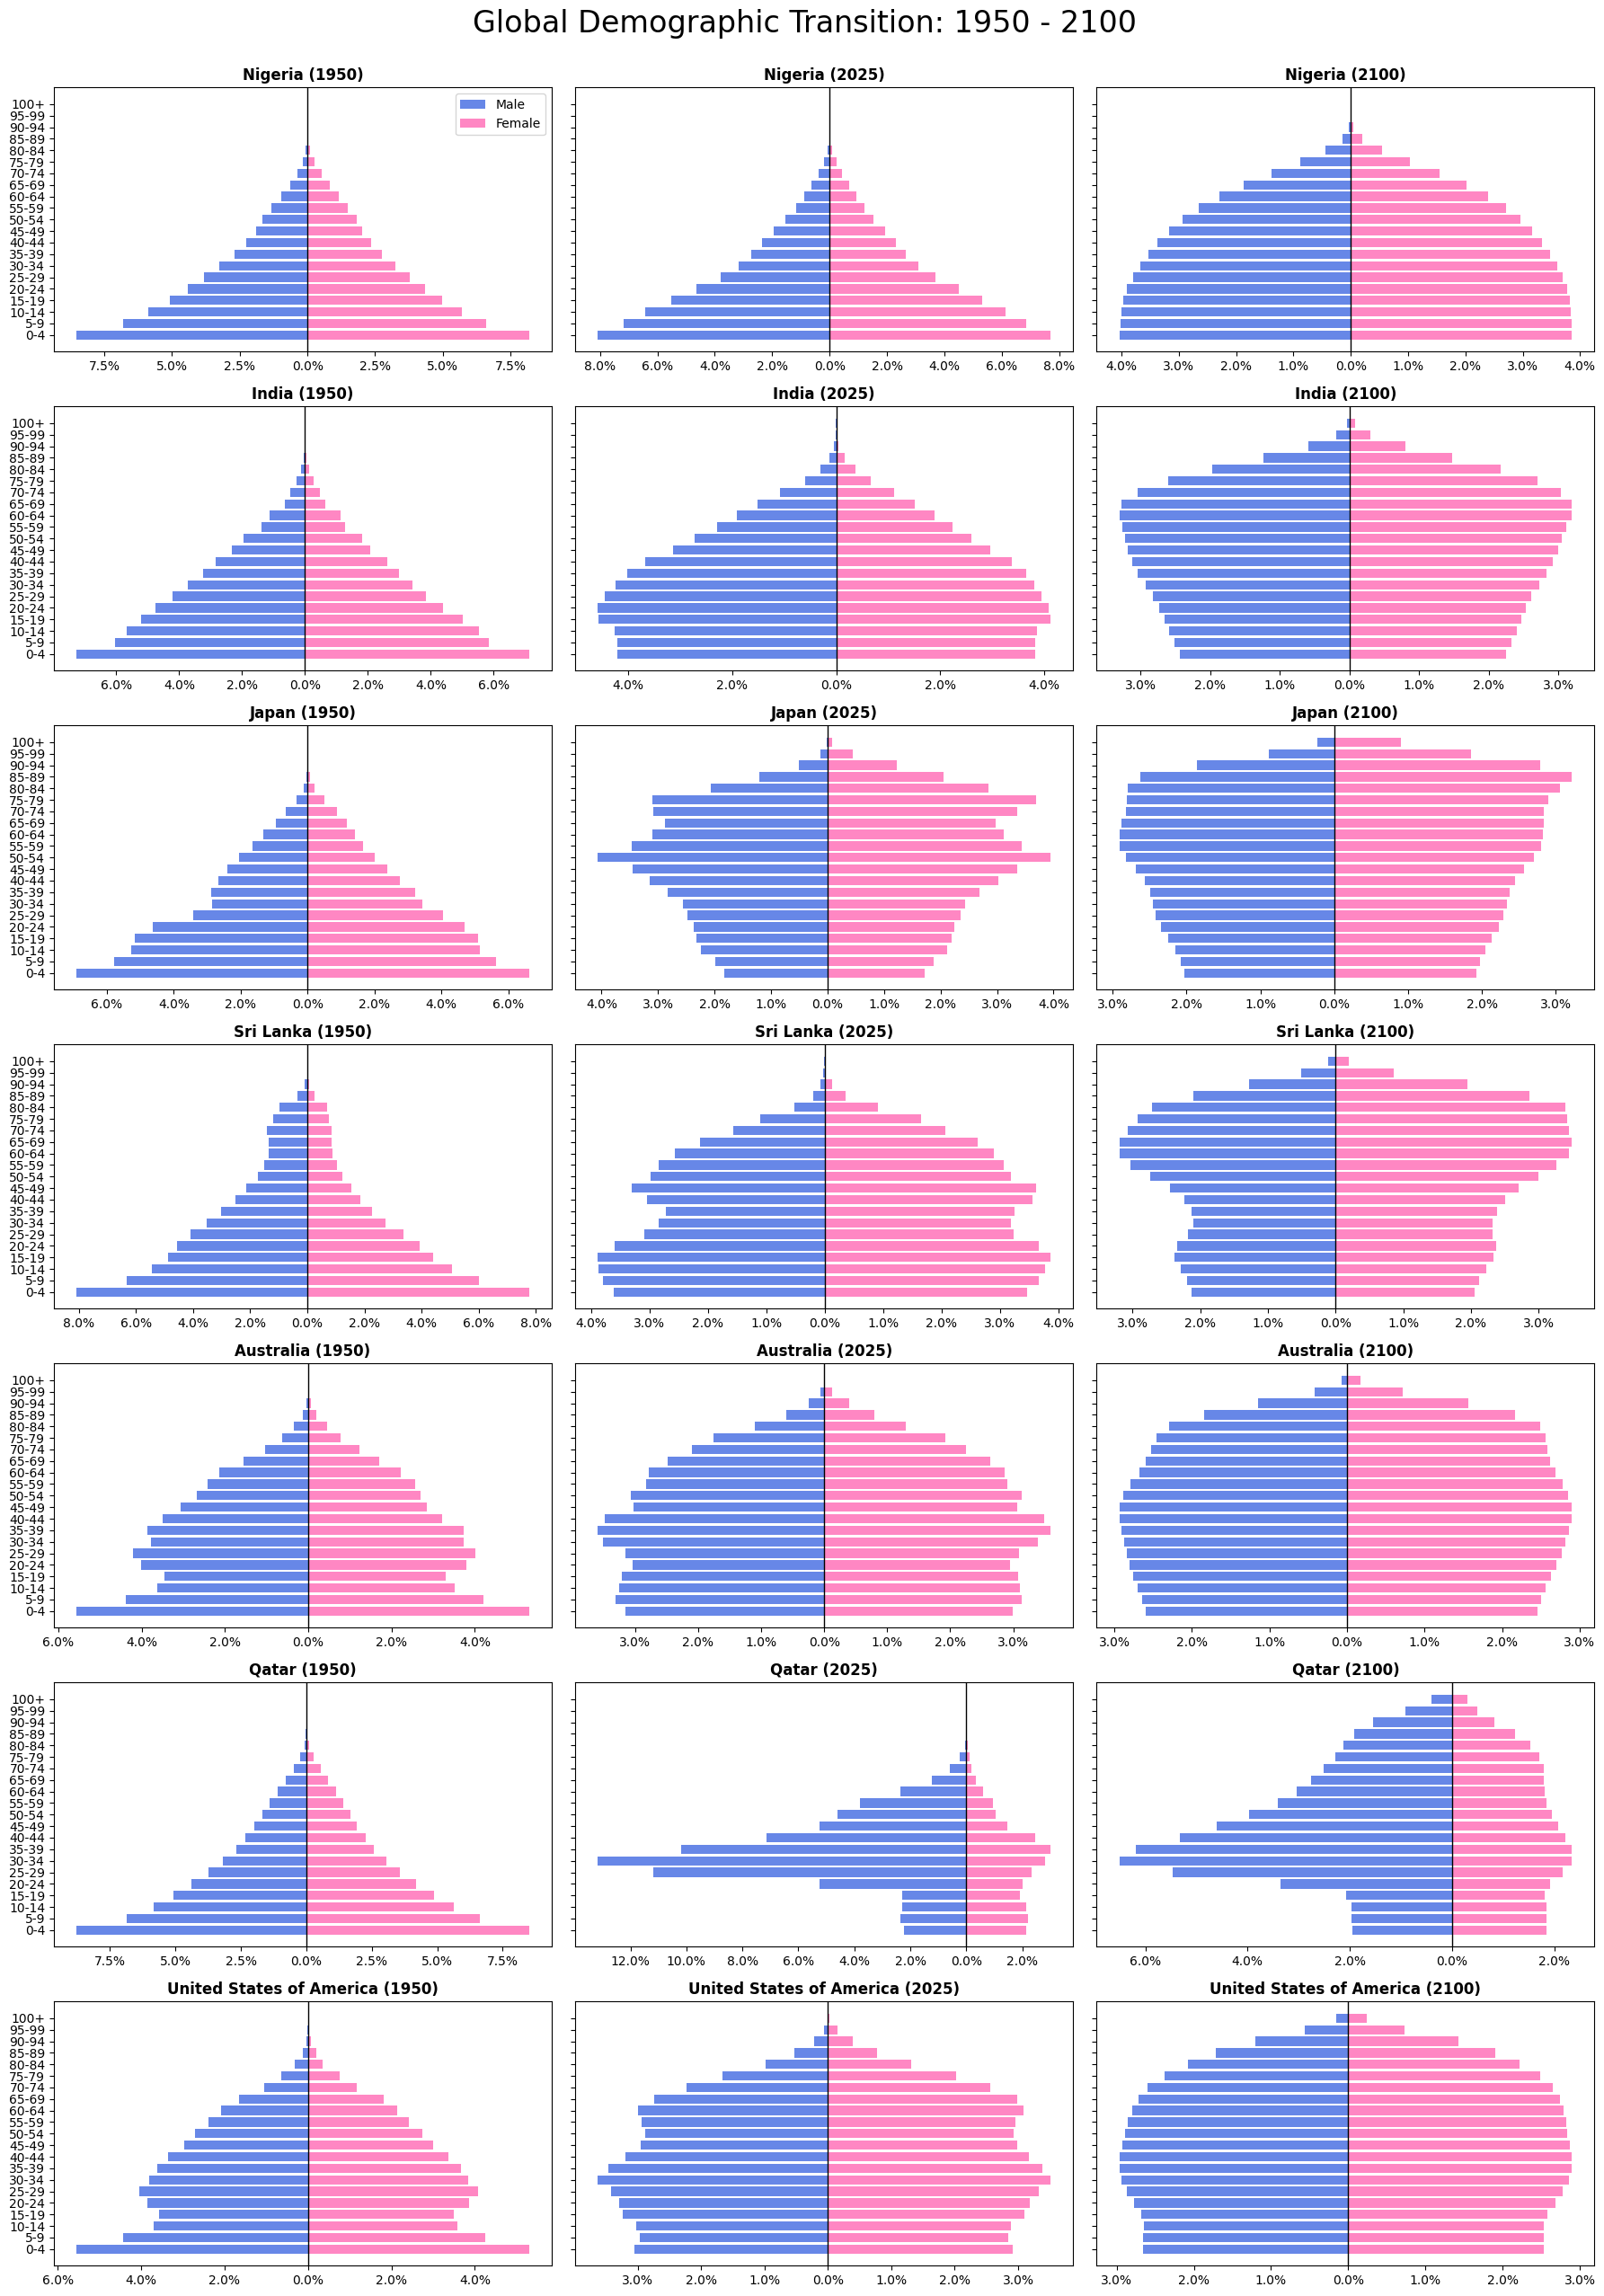

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Setup Sorting Helper
df = pd.read_csv('age_data_1.csv')

# This extracts numbers so "5-9" comes before "10-14"
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

# 2. Setup Countries and Years
target_countries = ['Nigeria', 'India', 'Japan', 'Sri Lanka', 'Australia', 'Qatar', 'United States of America']
target_years = [1950, 2025, 2100]

# 3. Create the Visualization Grid
fig, axes = plt.subplots(len(target_countries), len(target_years),
                         figsize=(18, 25), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Filter and SORT correctly
        data = df[(df['Location'] == country) & (df['Time'] == year)].sort_values('age_sort')

        if data.empty:
            ax.text(0.5, 0.5, f"No Data for {year}", ha='center')
            continue

        ages = data['AgeGrp']
        male_pop = data['PopMale']
        female_pop = data['PopFemale']

        # Calculate percentage for accurate shape comparison
        total = male_pop.sum() + female_pop.sum()
        m_pct = (male_pop / total) * 100
        f_pct = (female_pop / total) * 100

        # Plotting
        ax.barh(ages, -m_pct, color='royalblue', label='Male', alpha=0.8)
        ax.barh(ages, f_pct, color='hotpink', label='Female', alpha=0.8)
        ax.axvline(0, color='black', linewidth=1)

        # Formatting
        ax.set_title(f"{country} ({year})", fontsize=12, fontweight='bold')

        # Absolute value labels for X-axis
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.suptitle("Global Demographic Transition: 1950 - 2100", fontsize=24, y=1.02)
plt.show()

#DEmo. Ev.. from 1950 to 2100 Hierarchical

<>:10: SyntaxWarning:

invalid escape sequence '\d'

<>:10: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-2205508920.py:10: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipython-input-2205508920.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2205508920.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2205508920.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2205508920.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2205508920.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or

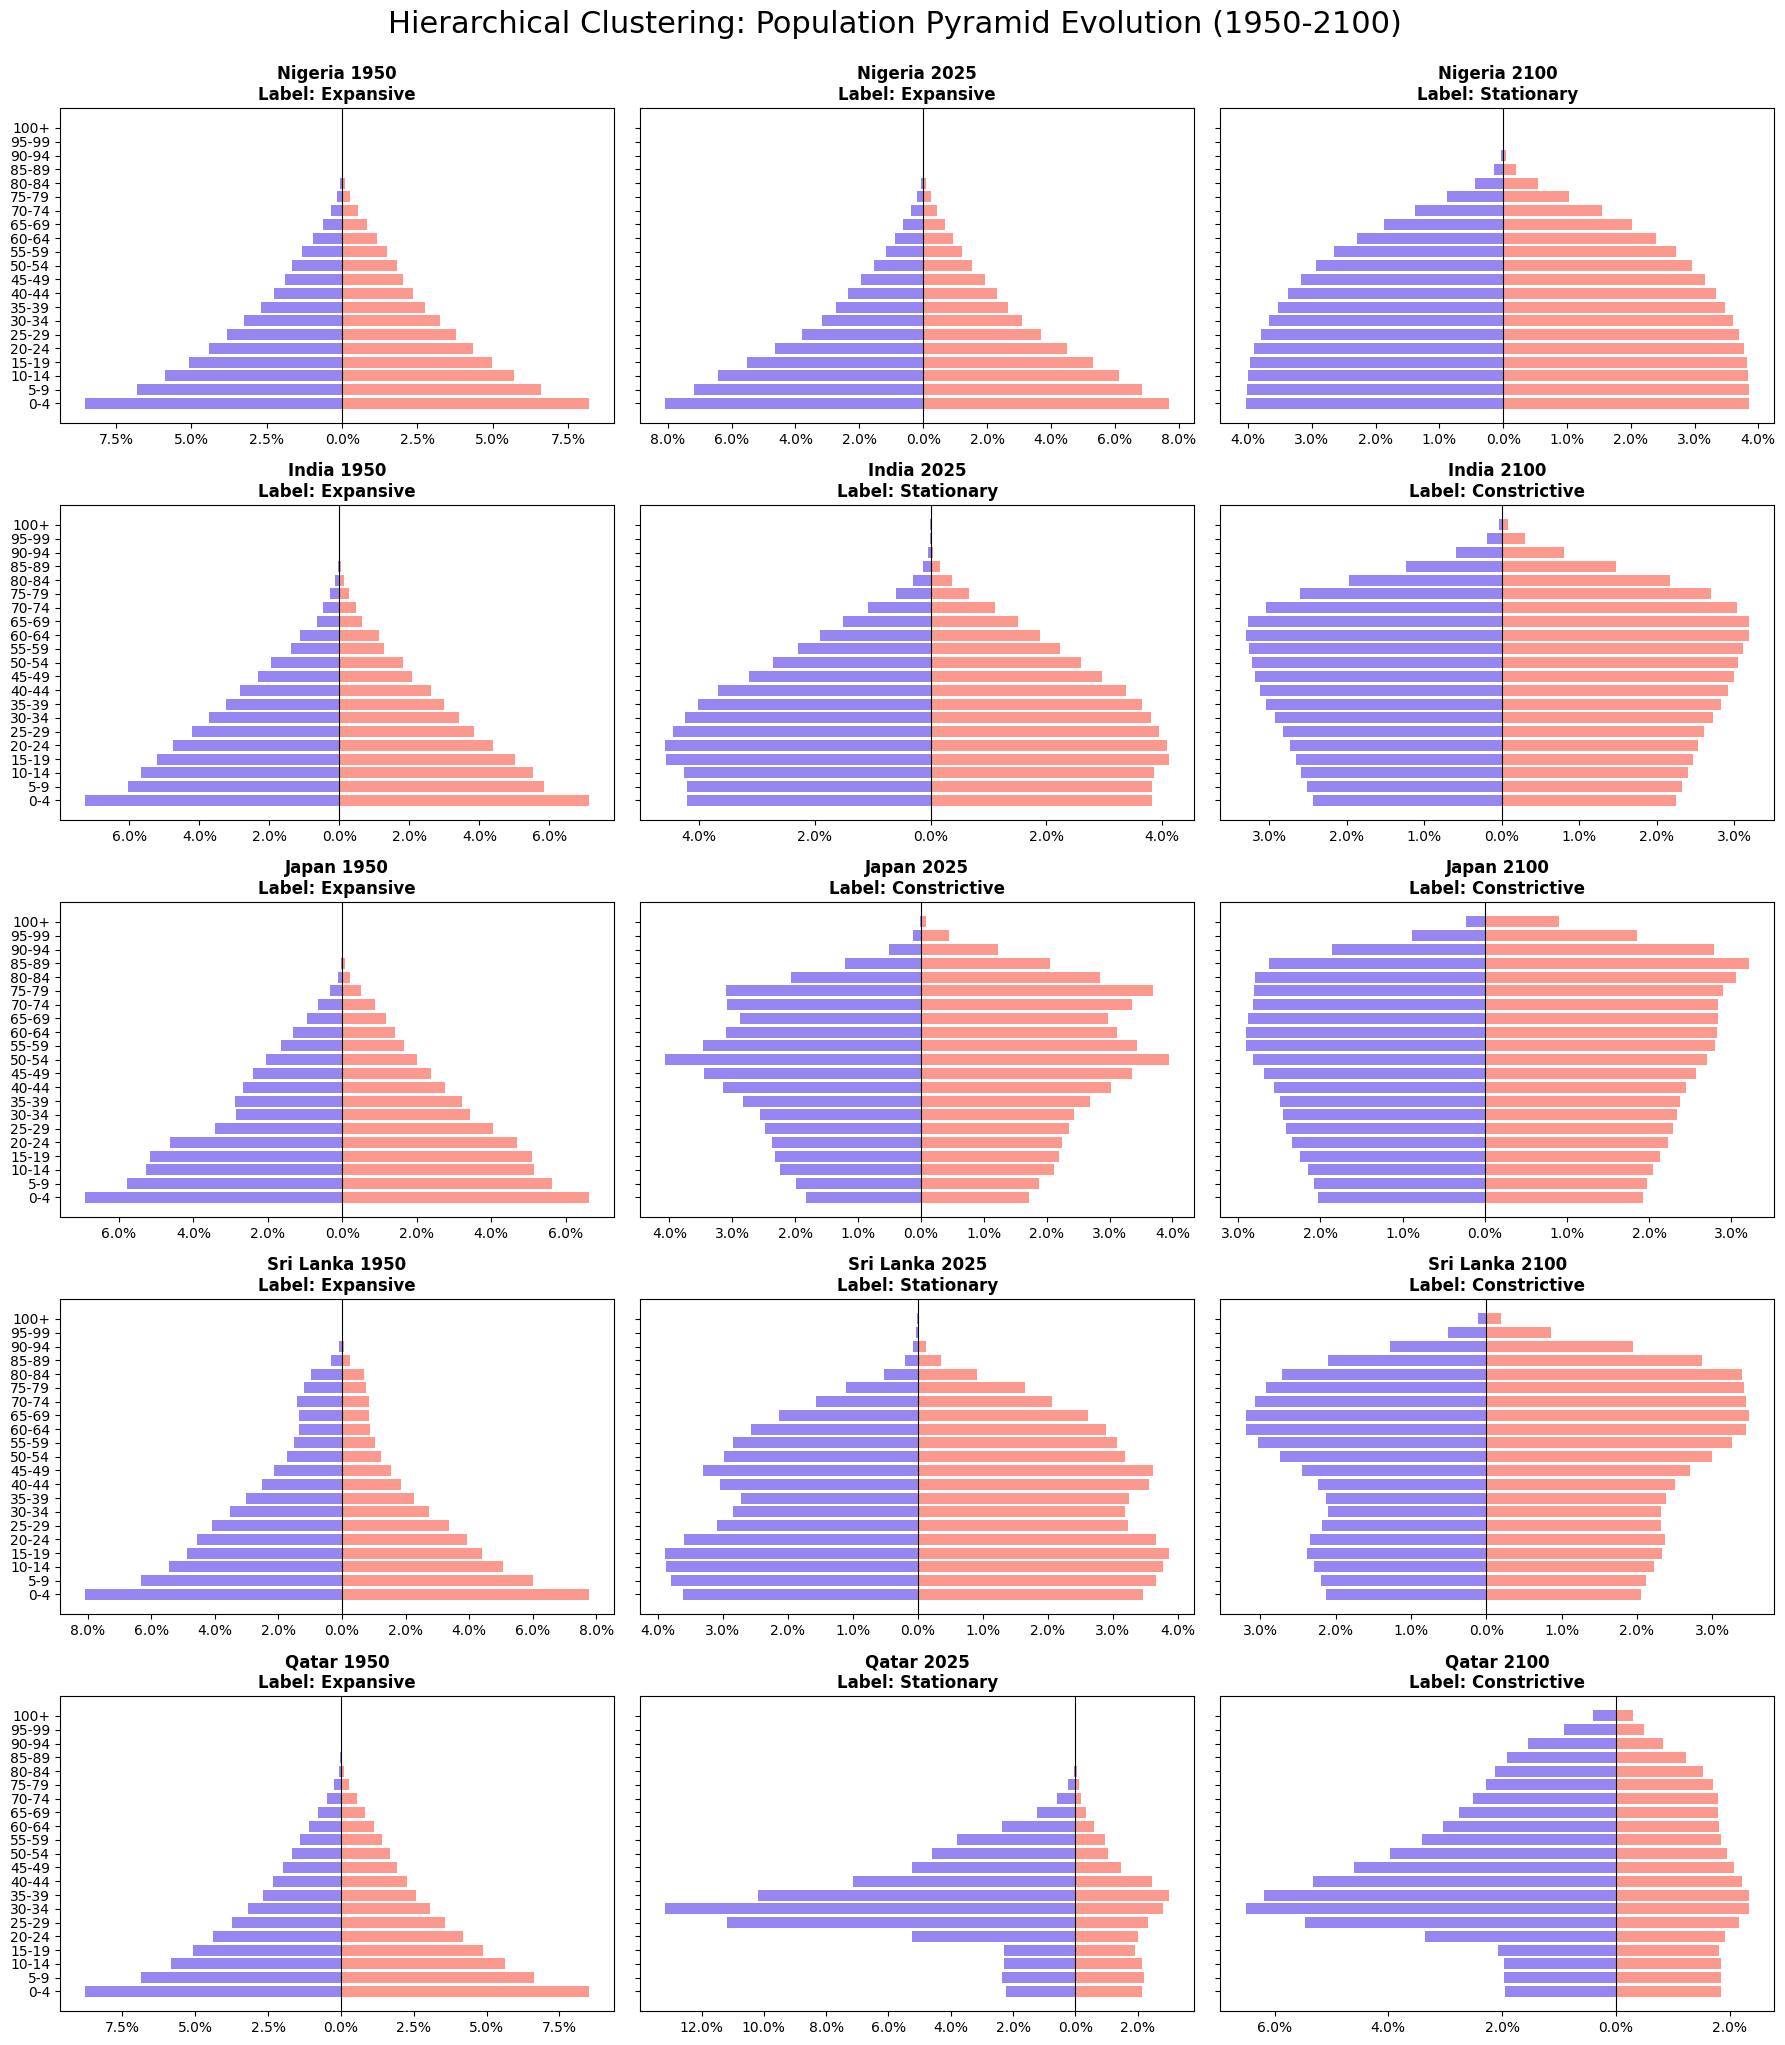

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. PREPARE DATA & SORTING HELPER ---
# Extract number from AgeGrp (e.g., "5-9" -> 5) to fix the plotting sequence
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

# Prepare Data for Hierarchical Labels
X_pivot_data = df.pivot_table(index=['Location', 'Time'], columns='AgeGrp', values='PopTotal').fillna(0)
X_pct_global = X_pivot_data.div(X_pivot_data.sum(axis=1), axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct_global)
X_pca_global = PCA(n_components=0.95).fit_transform(X_scaled)

# Fit Hierarchical Model
hc_global = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
X_pivot_data['HC_Cluster'] = hc_global.fit_predict(X_pca_global)

# Determine Labels based on youth percentage
# We use the first column (usually 0-4) to rank clusters by "youthfulness"
youth_col = X_pct_global.columns[0]
youth_order = X_pct_global.groupby(X_pivot_data['HC_Cluster'])[youth_col].mean().sort_values(ascending=False).index
hc_label_map = {youth_order[0]: "Expansive", youth_order[1]: "Stationary", youth_order[2]: "Constrictive"}

# --- 2. PLOTTING THE PYRAMIDS ---
target_countries = ['Nigeria', 'India', 'Japan', 'Sri Lanka', 'Qatar']
target_years = [1950, 2025, 2100]

fig, axes = plt.subplots(len(target_countries), len(target_years), figsize=(18, 20), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Filter and SORT using the age_sort helper
        country_data = df[(df['Location'] == country) & (df['Time'] == year)].sort_values('age_sort')

        if country_data.empty: continue

        # Retrieve the pre-calculated cluster label
        cluster_id = X_pivot_data.loc[(country, year), 'HC_Cluster']
        label = hc_label_map[cluster_id]

        # Percentages for scale
        total = country_data['PopTotal'].sum()
        m_pct = (country_data['PopMale'] / total) * 100
        f_pct = (country_data['PopFemale'] / total) * 100
        ages = country_data['AgeGrp']

        # Plot
        ax.barh(ages, -m_pct, color='mediumslateblue', alpha=0.8, label='Male')
        ax.barh(ages, f_pct, color='salmon', alpha=0.8, label='Female')

        # Styling
        ax.set_title(f"{country} {year}\nLabel: {label}", fontsize=12, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)

        # Formatting X-axis to show positive percentage values
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Hierarchical Clustering: Population Pyramid Evolution (1950-2100)", fontsize=22, y=1.02)
plt.show()